# 선형대수 실습: LU, QR, 고윳값, SVD

[고윳값과 케일리-해밀턴 정리](math5.md)와 [행렬 분해](math6.md)에서 정리한 내용을 직접 계산해서 확인한다.
정리는 그 두 노트에 있고, 이 노트북은 **숫자와 그림으로 확인하는 것**만 한다.

- **LU**: L과 U가 각각 무엇을 기록하는지, 우변 b가 바뀔 때 왜 싸지는지
- **QR**: 그람-슈미트가 만드는 직교 기저, 최소제곱으로 직선 맞추기
- **고윳값**: 변환해도 방향이 유지되는 벡터, power iteration, 케일리-해밀턴
- **대각화**: $A^n$ 을 $D^n$ 으로 계산하기 (피보나치 행렬)
- **SVD**: 특이값 감소와 rank-k 근사 = 압축

필요한 것은 numpy와 matplotlib뿐이다. 난수는 시드를 고정했으므로 누가 언제 돌려도 같은 값이 나온다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.set_printoptions(precision=4, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 90
rng = np.random.default_rng(42)

print("numpy", np.__version__, "/ matplotlib", plt.matplotlib.__version__)

numpy 2.5.3 / matplotlib 3.11.2


## 1. LU 분해 — 소거 과정을 두 행렬로 나눠 담기

가우스 소거를 그대로 하면 최종적으로 남는 것은 상삼각행렬 $U$ 다. 그런데 소거하면서 곱한 승수(multiplier)를 버리지 않고 따로 모아두면 하삼각행렬 $L$ 이 되고, $A = LU$ 가 성립한다.

- $U$: 소거가 끝난 뒤 남은 계수 (방정식이 정리된 결과)
- $L$: 각 단계에서 몇 배를 빼냈는지에 대한 기록, 대각선은 1

직접 만들어서 확인해보자.

In [2]:
def lu_decompose(A):
    """부분 피벗 없이 A = LU 로 분해한다. (L은 대각선이 1인 하삼각행렬)"""
    n = A.shape[0]
    U = A.astype(float).copy()
    L = np.eye(n)
    for k in range(n - 1):
        m = U[k + 1:, k] / U[k, k]        # k열을 지우기 위해 곱하는 소거 승수들
        L[k + 1:, k] = m                  # 승수를 버리지 않고 L에 기록
        U[k + 1:, k:] -= np.outer(m, U[k, k:])
        U[k + 1:, k] = 0.0                # 수치적으로 0이 된 자리 정리
    return L, U


A = np.array([[4.0, 3.0, 2.0],
              [2.0, 5.0, 3.0],
              [1.0, 2.0, 6.0]])

L, U = lu_decompose(A)
print("L =\n", L)
print("U =\n", U)
print("max|A - LU| =", np.abs(A - L @ U).max())
print("L의 비대각 원소 = 소거 승수:", np.round([v for v in L.flatten() if v != 1 and v != 0], 4))

L =
 [[1.     0.     0.    ]
 [0.5    1.     0.    ]
 [0.25   0.3571 1.    ]]
U =
 [[4.     3.     2.    ]
 [0.     3.5    2.    ]
 [0.     0.     4.7857]]
max|A - LU| = 0.0
L의 비대각 원소 = 소거 승수: [0.5    0.25   0.3571]


$A = LU$ 가 확인됐다. 이제 $Ax = b$ 를 풀 때 $LUx = b$ 를 $Ly = b$ (전진 대입) → $Ux = y$ (후진 대입) 두 단계로 나눠 푼다. 삼각행렬은 대입만으로 풀리므로 $O(n^2)$ 이면 끝난다.

In [3]:
def forward_substitution(L, B):
    """Ly = B 를 전진 대입으로 푼다. B는 (n,) 또는 (n, k) 모두 가능."""
    n = L.shape[0]
    Y = np.zeros_like(B, dtype=float)
    for i in range(n):
        Y[i] = B[i] - L[i, :i] @ Y[:i]
    return Y


def back_substitution(U, Y):
    """Ux = Y 를 후진 대입으로 푼다."""
    n = U.shape[0]
    X = np.zeros_like(Y, dtype=float)
    for i in range(n - 1, -1, -1):
        X[i] = (Y[i] - U[i, i + 1:] @ X[i + 1:]) / U[i, i]
    return X


b = np.array([1.0, 2.0, 3.0])
x_lu = back_substitution(U, forward_substitution(L, b))
print("LU로 푼 해 :", x_lu)
print("np.linalg.solve :", np.linalg.solve(A, b))
print("max|차이| =", np.abs(x_lu - np.linalg.solve(A, b)).max())

LU로 푼 해 : [-0.1045  0.1642  0.4627]
np.linalg.solve : [-0.1045  0.1642  0.4627]
max|차이| = 5.551115123125783e-17


### 왜 "한 번 분해하고 여러 번 대입"이 싸지는가

행렬은 그대로인데 우변 $b$ 만 계속 바뀌는 상황(같은 시스템에 입력 벡터를 반복해서 통과시키기)이 실무에서 자주 나온다.
매번 처음부터 분해하면 $O(n^3)$ 을 우변 개수만큼 반복하고, 한 번 분해해두면 이후에는 $O(n^2)$ 대입만 하면 된다.

$n=400$, 우변 200개로 시간을 재보자. 비용이 **어디에 몇 번** 쓰이는지가 요점이다.

In [4]:
import time


def timeit(fn):
    t0 = time.perf_counter()
    out = fn()
    return time.perf_counter() - t0, out


n, m = 400, 200
G = rng.normal(size=(n, n))
A_big = G.T @ G + 400 * np.eye(n)          # 대각 우세한 대칭행렬 (피벗 0 방지)
B = rng.normal(size=(n, m))

# (1) b 하나씩 매번 분해해서 풀기 -> 분해 200회
t_each, _ = timeit(lambda: [np.linalg.solve(A_big, B[:, j]) for j in range(m)])

# (2) 행렬 우변으로 한 번에 -> LAPACK이 분해 1회 + 대입 200회
t_batch, X_batch = timeit(lambda: np.linalg.solve(A_big, B))


# (3) 직접 분해 1회 + 대입 200회 (numpy만 사용)
def own():
    L_b, U_b = lu_decompose(A_big)
    return back_substitution(U_b, forward_substitution(L_b, B))


t_own, X_own = timeit(own)

print(f"(1) b 하나씩 매번 분해 (분해 {m}회)      : {t_each * 1000:8.1f} ms")
print(f"(2) 행렬 우변 한 번에 (분해 1회, LAPACK) : {t_batch * 1000:8.1f} ms")
print(f"(3) 직접 LU 1회 + 대입 (분해 1회, numpy) : {t_own * 1000:8.1f} ms")
print(f"-> 분해를 {m}번 한 (1)은 (2)보다 {t_each / t_batch:.0f}배 느리다")
print(f"-> 직접 구현한 (3)은 LAPACK보다 느리지만, (1)보다는 {t_each / t_own:.1f}배 빠르다")
print("세 방법의 해는 같은가:", np.allclose(X_batch, X_own, atol=1e-6))

(1) b 하나씩 매번 분해 (분해 200회)      :     87.3 ms
(2) 행렬 우변 한 번에 (분해 1회, LAPACK) :      0.8 ms
(3) 직접 LU 1회 + 대입 (분해 1회, numpy) :     23.0 ms
-> 분해를 200번 한 (1)은 (2)보다 110배 느리다
-> 직접 구현한 (3)은 LAPACK보다 느리지만, (1)보다는 3.8배 빠르다
세 방법의 해는 같은가: True


직접 구현한 (3)이 LAPACK(2)보다 느린 것은 구현 상수의 차이다. 여기서 볼 것은 **분해 횟수(200회 → 1회)** 다.

분해를 한 번만 했다면 우변을 늘리는 비용은 얼마나 될까. 대입이 $O(n^2)$ 이므로 우변 개수에 선형으로만 늘어나야 한다.

In [5]:
B_big = rng.normal(size=(n, 800))
grow = {}
for k in (1, 200, 800):
    grow[k], _ = timeit(lambda kk=k: np.linalg.solve(A_big, B_big[:, :kk]))

per_rhs = (grow[800] - grow[1]) / 799
per_full = t_each / m
print(f"우변 1개   : {grow[1] * 1000:7.2f} ms   (분해 비용이 대부분)")
print(f"우변 200개 : {grow[200] * 1000:7.2f} ms")
print(f"우변 800개 : {grow[800] * 1000:7.2f} ms")
print(f"-> 분해 후 우변 1개 추가 비용 ≈ {per_rhs * 1e6:6.0f} µs  (O(n^2) 대입만)")
print(f"-> 매번 분해했다면 우변 1개당   ≈ {per_full * 1e6:6.0f} µs  ({per_full / per_rhs:.0f}배)")
print("   (ms 단위 측정이라 µs 값은 어림값이다. 추세만 보면 된다)")

우변 1개   :    0.58 ms   (분해 비용이 대부분)
우변 200개 :    0.85 ms
우변 800개 :    2.28 ms
-> 분해 후 우변 1개 추가 비용 ≈      2 µs  (O(n^2) 대입만)
-> 매번 분해했다면 우변 1개당   ≈    437 µs  (205배)
   (ms 단위 측정이라 µs 값은 어림값이다. 추세만 보면 된다)


## 2. QR 분해 — 직교 기저로 바꾸면 최소제곱이 쉬워진다

그람-슈미트는 $A$ 의 열 벡터들을 **서로 직교하는 기저**로 정리한다. 그 결과가 $A = QR$ 이고 $Q$ 는 $Q^TQ = I$ 를 만족한다.

정사각행렬이 아니어도 분해할 수 있다는 점이 중요하다. 데이터가 방정식보다 많은(과결정) 최소제곱 문제에서 정규방정식 $A^TAx = A^Tb$ 대신 $Rx = Q^Tb$ 를 풀면 조건수가 $A^TA$ 만큼 나빠지지 않는다.

Q^T Q = I 인가: True
max|A - QR| = 1.1102230246251565e-16
QR 최소제곱 해 : [2.3353 1.7725]
np.linalg.lstsq: [2.3353 1.7725]


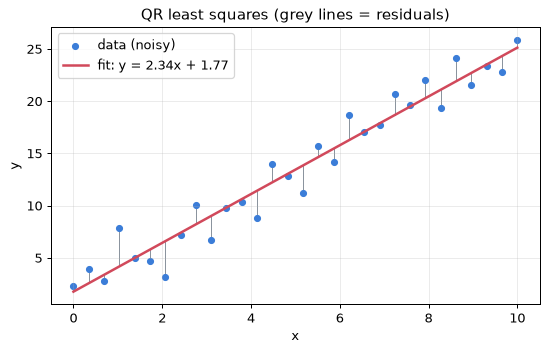

잔차 제곱합 = 82.8990000975827


In [6]:
def qr_gram_schmidt(A):
    """고전 그람-슈미트로 A = QR 을 만든다."""
    n, m = A.shape
    Q = np.zeros((n, m))
    R = np.zeros((m, m))
    for j in range(m):
        v = A[:, j].astype(float).copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ A[:, j]      # 기존 기저 방향 성분
            v -= R[i, j] * Q[:, i]           # 그 성분을 빼서 직교화
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]                # 정규화
    return Q, R


xs = np.linspace(0, 10, 30)
ys = 2.5 * xs + 1.0 + rng.normal(scale=1.5, size=xs.size)   # 직선 + 잡음
A_fit = np.column_stack([xs, np.ones_like(xs)])             # [기울기, 절편]

Q, R = qr_gram_schmidt(A_fit)
print("Q^T Q = I 인가:", np.allclose(Q.T @ Q, np.eye(2)))
print("max|A - QR| =", np.abs(A_fit - Q @ R).max())

coef_qr = back_substitution(R, Q.T @ ys)      # Rx = Q^T b
coef_np = np.linalg.lstsq(A_fit, ys, rcond=None)[0]
print("QR 최소제곱 해 :", coef_qr)
print("np.linalg.lstsq:", coef_np)

residual = ys - A_fit @ coef_qr
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(xs, ys, s=22, color="#3b7dd8", label="data (noisy)")
ax.plot(xs, A_fit @ coef_qr, color="#d1495b", lw=2,
        label=f"fit: y = {coef_qr[0]:.2f}x + {coef_qr[1]:.2f}")
for xi, yi, ri in zip(xs, ys, residual):
    ax.plot([xi, xi], [yi, yi - ri], color="#8b949e", lw=0.8, zorder=0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("QR least squares (grey lines = residuals)")
ax.legend()
ax.grid(alpha=0.25)
plt.show()
print("잔차 제곱합 =", float(residual @ residual))

## 3. 고윳값 — 변환해도 방향이 유지되는 벡터

$A\mathbf{v} = \lambda\mathbf{v}$ 를 그림으로 보면, 단위원의 모든 점이 $A$ 를 지나면서 타원으로 늘어나는데 **고유벡터 방향의 점들만 회전하지 않고 그 방향 위에서 늘어난다.** 늘어난 배율이 고윳값이다.

고윳값: [1. 3.]   고유벡터(열):
 [[-0.7071  0.7071]
 [ 0.7071  0.7071]]


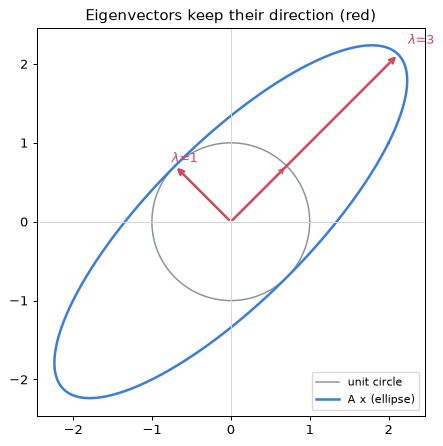

In [7]:
A2 = np.array([[2.0, 1.0], [1.0, 2.0]])       # 대칭행렬 -> 고윳값이 항상 실수
vals, vecs = np.linalg.eigh(A2)               # 대칭/에르미트 전용 (실수 고윳값)
print("고윳값:", vals, "  고유벡터(열):\n", vecs)

theta = np.linspace(0, 2 * np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])
ellipse = A2 @ circle

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot(circle[0], circle[1], color="#8b949e", lw=1.2, label="unit circle")
ax.plot(ellipse[0], ellipse[1], color="#3b7dd8", lw=2, label="A x (ellipse)")
for k in range(2):
    v = vecs[:, k]
    av = A2 @ v
    ax.annotate("", xy=av, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="#d1495b", lw=2))
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="#d1495b", lw=1, ls="dashed"))
    ax.text(av[0] * 1.06, av[1] * 1.06, f"$\\lambda$={vals[k]:.0f}", color="#d1495b")
ax.set_aspect("equal")
ax.axhline(0, color="#d0d7de", lw=0.8)
ax.axvline(0, color="#d0d7de", lw=0.8)
ax.set_title("Eigenvectors keep their direction (red)")
ax.legend(loc="lower right", fontsize=9)
plt.show()

고유벡터 방향은 화살표가 회전하지 않고 길이만 바뀌는 것을 볼 수 있다. 이 고윳값을 **거듭제곱법(power iteration)** 으로 직접 찾아보자. 방식은 단순하다: 아무 벡터나 잡고 $A$ 를 계속 곱하면서 정규화하면, 가장 큰 고윳값 방향 성분만 살아남는다.

np.linalg.eigvals: [5.+0.j 2.+0.j] -> 최대 고윳값 5.0
power iteration 결과: 5.000000 / 반복 30회
수렴 비율 |λ2/λ1| = 0.40 -> 오차가 매 반복마다 이 비율로 줄어든다


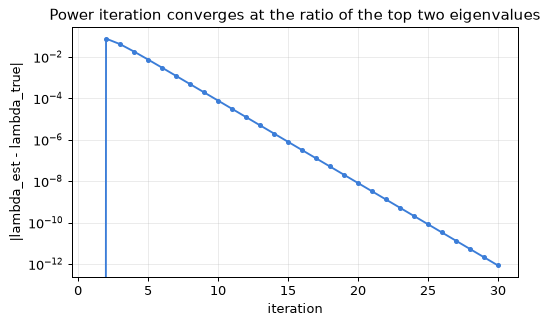

In [8]:
A3 = np.array([[4.0, 1.0], [2.0, 3.0]])            # 고윳값 5, 2
true_vals = np.linalg.eigvals(A3)
lam_true = true_vals[np.argmax(np.abs(true_vals))].real
print("np.linalg.eigvals:", true_vals, "-> 최대 고윳값", lam_true)

v = np.array([1.0, 0.0])
history = []
for _ in range(30):
    v = A3 @ v
    v = v / np.linalg.norm(v)                      # 정규화 (스케일 폭주 방지)
    lam = v @ A3 @ v                               # 레일리 몫
    history.append(abs(lam - lam_true))

print("power iteration 결과:", f"{v @ A3 @ v:.6f}", "/ 반복 30회")
print("수렴 비율 |λ2/λ1| =", f"{2 / 5:.2f}", "-> 오차가 매 반복마다 이 비율로 줄어든다")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.semilogy(range(1, 31), history, marker="o", ms=3, color="#3b7dd8")
ax.set_xlabel("iteration")
ax.set_ylabel("|lambda_est - lambda_true|")
ax.set_title("Power iteration converges at the ratio of the top two eigenvalues")
ax.grid(alpha=0.25, which="both")
plt.show()

### 케일리-해밀턴 정리 확인

$2\times2$ 행렬의 특성방정식은 $\lambda^2 - \mathrm{tr}(A)\lambda + \det(A) = 0$ 이고, 행렬도 같은 식을 만족한다: $A^2 - \mathrm{tr}(A)A + \det(A)I = 0$.

무작위 행렬 200개로 확인해보자.

In [9]:
residuals = []
for _ in range(200):
    M = rng.normal(size=(2, 2))
    res = M @ M - np.trace(M) * M + np.linalg.det(M) * np.eye(2)
    residuals.append(np.abs(res).max())

print("무작위 2x2 200개에서 max|A^2 - tr(A)A + det(A)I| =", f"{max(residuals):.3e}")
print("-> 부동소수점 오차 범위에서 항상 0 (정리 확인)")

M = A2
print("\n예시 A =\n", M)
print("tr(A) =", np.trace(M), ", det(A) =", np.linalg.det(M))
print("A^2 - tr(A)A + det(A)I =\n", M @ M - np.trace(M) * M + np.linalg.det(M) * np.eye(2))

무작위 2x2 200개에서 max|A^2 - tr(A)A + det(A)I| = 1.776e-15
-> 부동소수점 오차 범위에서 항상 0 (정리 확인)

예시 A =
 [[2. 1.]
 [1. 2.]]
tr(A) = 4.0 , det(A) = 2.9999999999999996
A^2 - tr(A)A + det(A)I =
 [[-0.  0.]
 [ 0. -0.]]


## 4. 대각화 — $A^n$ 을 $D^n$ 으로 계산하기

고유벡터를 새 축으로 삼으면 $A = PDP^{-1}$ 이 되고, $A^n = PD^nP^{-1}$ 이다. $D$ 는 대각행렬이라 거듭제곱이 원소별 거듭제곱으로 끝난다. 행렬을 $n$ 번 곱하는 것과 고윳값에 $n$ 승을 하는 것은 완전히 다른 비용이다.

피보나치 수열을 행렬로 만든 $A = \begin{pmatrix}1&1\\1&0\end{pmatrix}$ 로 확인한다. $A^n = \begin{pmatrix}F_{n+1}&F_n\\F_n&F_{n-1}\end{pmatrix}$ 이다.

고윳값: φ = 1.618034 -> 동시에 [ 1.618+0.j -0.618+0.j]
    n        대각화 (float64)         정확한 값의 자릿수         상대오차
   10         5.500000e+01                  2     1.29e-16
  100         3.542248e+20                 21     3.70e-15
  300         2.222322e+62                 63     1.13e-14
  500        1.394232e+104                105     1.84e-14
  800        6.928308e+166                167     2.93e-14
 1000        4.346656e+208                209     3.67e-14
 1200        2.726988e+250                251     4.41e-14
 1400        1.710848e+292                293     5.14e-14


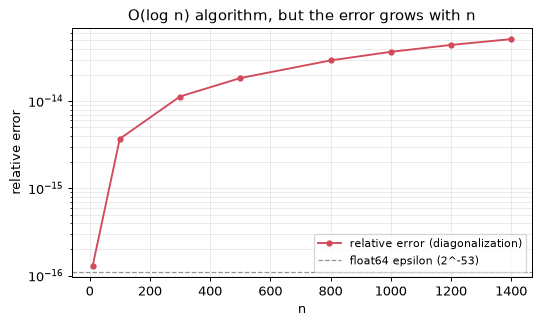


float64가 감당하는 마지막 지점
phi^1500 = inf  (float64 최대 ≈ 1.8e308)
fib_diag(1500) = nan
정수 반복(정확)은 계속 계산된다: 3354898000 ... (뒤 10자리)


In [10]:
F = np.array([[1.0, 1.0], [1.0, 0.0]])
w, P = np.linalg.eig(F)
Pinv = np.linalg.inv(P)
print("고윳값: φ =", f"{(1 + 5 ** 0.5) / 2:.6f}", "-> 동시에", w)


def fib_diag(n):
    """A^n = P D^n P^-1 을 이용한 피보나치. 부동소수점 연산."""
    return (P @ np.diag(w ** n) @ Pinv)[0, 1].real


def fib_iter(n):
    """정수 반복 (정확한 기준값)."""
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


print(f"{'n':>5} {'대각화 (float64)':>20} {'정확한 값의 자릿수':>18} {'상대오차':>12}")
ns, errs = [10, 100, 300, 500, 800, 1000, 1200, 1400], []
for n in ns:
    approx, exact = fib_diag(n), fib_iter(n)
    err = abs(approx - exact) / exact
    errs.append(err)
    print(f"{n:>5} {approx:>20.6e} {len(str(exact)):>18d} {err:>12.2e}")

fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.semilogy(ns, errs, marker="o", ms=4, color="#d1495b", label="relative error (diagonalization)")
ax.axhline(2.0 ** -53, color="#8b949e", ls="--", lw=1, label="float64 epsilon (2^-53)")
ax.set_xlabel("n")
ax.set_ylabel("relative error")
ax.set_title("O(log n) algorithm, but the error grows with n")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=9)
plt.show()

print("\nfloat64가 감당하는 마지막 지점")
phi = (1 + 5 ** 0.5) / 2
with np.errstate(over="ignore"):
    print("phi^1500 =", float(np.float64(phi) ** 1500), " (float64 최대 ≈ 1.8e308)")
    print("fib_diag(1500) =", float(fib_diag(1500)))
    print("정수 반복(정확)은 계속 계산된다:", fib_iter(1500) % 10 ** 10, "... (뒤 10자리)")

고윳값 $\varphi \approx 1.618$ 의 $n$ 승 한 번이면 끝나므로 계산은 빠르다. 그런데 $\varphi$ 는 무리수라서 반올림 오차가 $n$ 에 따라 쌓이고(위 표의 상대오차가 $n$ 과 함께 커진다), $\varphi^n$ 이 float64가 표현할 수 있는 범위를 넘는 순간 값 자체가 무너진다.

**빠른 것과 정확한 것은 별개**다. 큰 $n$ 이 필요하면 정수 연산(빠른 배가법)을 쓴다.

## 5. SVD — 특이값이 급감하면 압축할 수 있다

LU와 QR이 연립방정식을 푸는 계산 도구라면, SVD는 **데이터의 본질적인 랭크**를 드러낸다. $A = U\Sigma V^T$ 에서 특이값 $\sigma$ 가 큰 순서로 정렬되므로, 뒤쪽을 버려도 정보 손실이 작다.

랭크 8짜리 행렬에 잡음을 조금 섞고, 특이값 스펙트럼이 어떻게 나오는지 본다.

행렬 크기 (200, 200)
수치적 랭크 (잡음 때문에 꽉 찬다): 200
상위 15개 특이값: [255.408 231.205 210.797 193.649 184.407 181.833 161.973 148.452   8.164   8.115   7.961   7.83    7.648
   7.612   7.533]
16~30번째: [7.4237 7.3901 7.314  7.2323 7.1469 7.0881 7.0486 7.0182 6.8535 6.8245 6.7806 6.736  6.6815 6.664  6.6089]


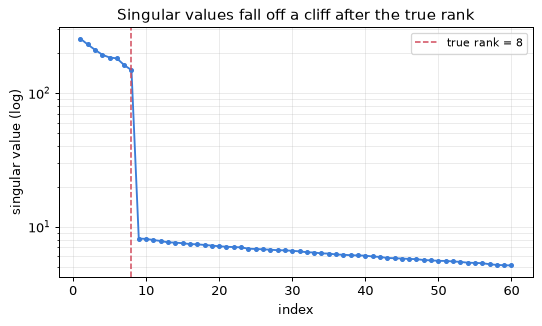

In [11]:
rank_true, size, noise = 8, 200, 0.3
M = rng.normal(size=(size, rank_true)) @ rng.normal(size=(rank_true, size))
M_noisy = M + noise * rng.normal(size=(size, size))

U, s, Vt = np.linalg.svd(M_noisy, full_matrices=False)
print(f"행렬 크기 {M_noisy.shape}")
print("수치적 랭크 (잡음 때문에 꽉 찬다):", np.linalg.matrix_rank(M_noisy))
print("상위 15개 특이값:", np.round(s[:15], 3))
print("16~30번째:", np.round(s[15:30], 4))

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.semilogy(np.arange(1, 61), s[:60], marker="o", ms=3, color="#3b7dd8")
ax.axvline(rank_true, color="#d1495b", ls="--", lw=1.2, label=f"true rank = {rank_true}")
ax.set_xlabel("index")
ax.set_ylabel("singular value (log)")
ax.set_title("Singular values fall off a cliff after the true rank")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=9)
plt.show()

잡음의 Frobenius 노름 = 60.0  (원본 노름 565.1의 10.6%)
-> 이 아래로는 k를 올려도 오차가 줄지 않는다

  k  Frobenius error   relative  storage vs full
  2          447.901    79.265%            2.00%
  4          344.500    60.966%            4.01%
  8           57.769    10.223%            8.02%
 16           53.402     9.451%           16.04%
 32           45.705     8.088%           32.08%


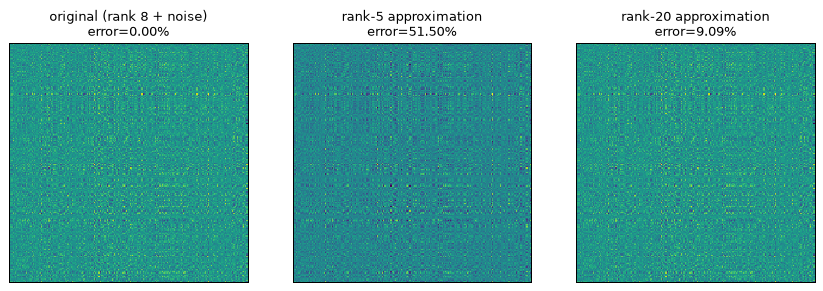

In [12]:
def rank_k(k):
    return (U[:, :k] * s[:k]) @ Vt[:k]


base = np.linalg.norm(M_noisy)
noise_fro = noise * np.sqrt(size * size)
print(f"잡음의 Frobenius 노름 = {noise_fro:.1f}  (원본 노름 {base:.1f}의 {noise_fro / base:.1%})")
print("-> 이 아래로는 k를 올려도 오차가 줄지 않는다\n")

print(f"{'k':>3} {'Frobenius error':>16} {'relative':>10} {'storage vs full':>16}")
for k in (2, 4, 8, 16, 32):
    err = np.linalg.norm(M_noisy - rank_k(k))
    print(f"{k:>3} {err:>16.3f} {err / base:>10.3%} {k * (size + size + 1) / (size * size):>16.2%}")

fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2))
for ax, k, title in zip(axes, (None, 5, 20),
                        ("original (rank 8 + noise)", "rank-5 approximation", "rank-20 approximation")):
    img = M_noisy if k is None else rank_k(k)
    ax.imshow(img, cmap="viridis", interpolation="nearest")
    ax.set_title(f"{title}\nerror={np.linalg.norm(M_noisy - img) / base:.2%}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()

특이값 8개 뒤로 값이 급격히 떨어지고, rank-8 근사만으로도 원본과 거의 같은 그림이 나온다. 저장량은 $\frac{k(m+n+1)}{mn}$ 로 줄어든다 — 위 표의 마지막 열이 압축률이다.

표에서 오차가 10% 근처에서 멈추는 것도 같이 봐야 한다. 여기서는 섞은 잡음이 그대로 바닥이 되기 때문이다(잡음의 Frobenius 노름이 원본의 10% 정도). **랭크를 올려도 잡음은 되찾을 수 없다**는 것이 SVD를 쓸 때의 기본 감각이다.

이미지 압축, 잠재 의미 분석(LSA), PCA, 노이즈 제거가 전부 이 하나의 성질에서 나온다.

## 정리: 어떤 분해를 언제 쓰는가

| 분해 | 나눠 담는 것 | 쓰는 상황 | 이 노트북에서 확인한 것 |
| --- | --- | --- | --- |
| $A = LU$ | 소거 승수($L$) + 남은 계수($U$) | 같은 행렬로 우변만 반복해서 풀 때 | 분해 200회 → 1회로 줄이면 LAPACK 기준 100배 이상, 우변 추가 비용은 $O(n^2)$ |
| $A = QR$ | 직교 기저($Q$) + 계수($R$) | 최소제곱, 수치적으로 안정한 해 | 잡음 낀 데이터에 직선이 맞춰지고 $Q^TQ=I$ 확인 |
| $A = PDP^{-1}$ | 방향($P$) + 배율($D$) | 변환의 본질 파악, $A^n$ 계산 | $\varphi^n$ 한 번으로 피보나치 계산, $n$ 이 커지면 오차 누적·오버플로 |
| $A = U\Sigma V^T$ | 직교 기저 두 쌍 + 특이값 | 압축, 랭크 확인, 잠재 요인 | 특이값 절벽 + rank-k 근사, 잡음 바닥 아래로는 줄지 않음 |

### 이 노트북에서 얻어야 하는 감각

1. 분해는 **계산을 줄이는 도구**다. LU는 반복 횟수를, SVD는 저장량을 줄인다.
2. 고윳값은 **변환의 방향과 배율**이다. 회귀, 진동, 페이지랭크가 전부 같은 질문을 한다.
3. 빠른 것과 정확한 것은 다르다. 대각화로 $A^n$ 을 구하면 빠르지만 부동소수점 한계가 있다.
4. 부동소수점 결과는 항상 **잔차로 검증**한다. 이 노트북의 `max|A - LU|`, `np.allclose` 가 그 역할이다.

## 실행 방법

```
pip install numpy matplotlib jupyter
jupyter lab Math/linear_algebra_lab.ipynb
```

출력은 커밋되어 있어서 GitHub에서 바로 볼 수 있고, 시드가 고정이라 다시 실행해도 같은 숫자가 나온다.